In [2]:
import pandas as pd
import numpy as np

In [3]:
wagner_data = pd.read_csv('py_out/wagner_1988_data.csv')
kobayashi_data = pd.read_csv('py_out/kobayashi_1991_data.csv')
burrows_data = pd.read_csv('py_out/burrows_1994_data.csv')
dupuy_data = pd.read_csv('py_out/dupuy_1995_data.csv')
weise_biging_data = pd.read_csv('py_out/weise_biging_1997_data.csv')

data_sets = [
    wagner_data,
    kobayashi_data,
    burrows_data,
    dupuy_data,
    weise_biging_data
]

data_set_names = [
    "Red pine needles (Van Wagner 1988)",
    "Loblolly pine needles (Kobayashi et al. 1991)",
    "Eucalypt litter (Burrows 1994)",
    "Allepo pine needles (Dupuy 1995)",
    "Paper birch sticks (Weise and Biging 1997)"
]

In [4]:
def scatter(ax, df, name, m, color, s_val, hollow = False):
    return ax.scatter(
        df["theta_deg"], 
        df["R_normalized"],
        s = s_val,
        linewidths = 0.5,
        label = name,
        marker = m,
        facecolors = 'none' if hollow else color,
        edgecolors = color
    )

In [5]:
noble_const_deg = 0.069
def noble(theta):
    return np.exp(noble_const_deg * theta)

In [6]:
def kataburn_A(theta):
    return 1/(2 - noble(theta))

In [7]:
def kataburn_B(theta):
    return 1/(2 * np.cos(np.radians(theta)) - noble(theta))

In [8]:
def theoretical(theta, c):
    return 1/(1 + c * np.tan(np.radians(theta)))

/tmp/ipykernel_32825/2833353436.py:2: UserWarning: You passed an edgecolor/edgecolors ('red') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(
/tmp/ipykernel_32825/2833353436.py:2: UserWarning: You passed an edgecolor/edgecolors ('green') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(


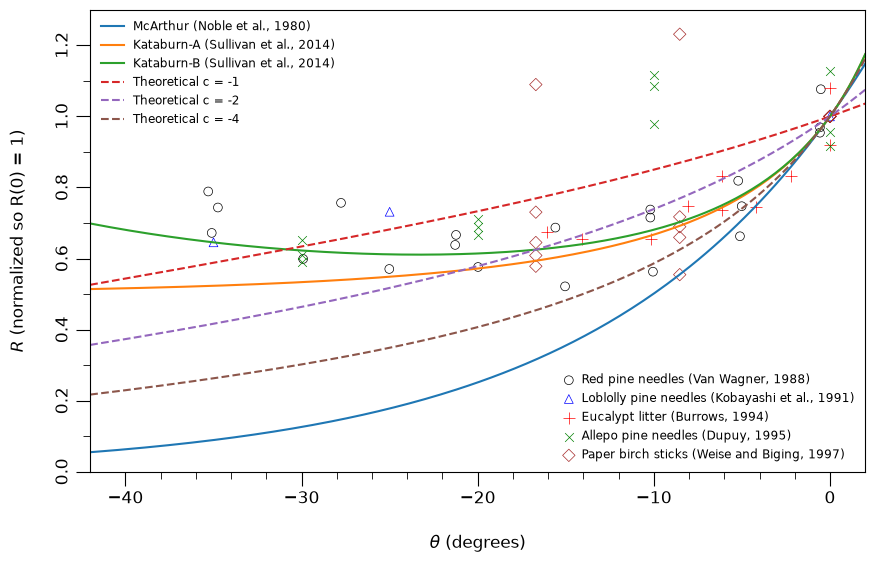

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

scatter_handles = [
        scatter(ax, wagner_data, "Red pine needles (Van Wagner, 1988)", 
                'o', 'black', 40 ,True),
        scatter(ax, kobayashi_data, "Loblolly pine needles (Kobayashi et al., 1991)",
                '^', 'blue', 40, True),
        scatter(ax, burrows_data, "Eucalypt litter (Burrows, 1994)",
                '+', 'red', 80),
        scatter(ax, dupuy_data, "Allepo pine needles (Dupuy, 1995)", 
                'x', 'green', 40),
        scatter(ax, weise_biging_data, "Paper birch sticks (Weise and Biging, 1997)",
                'D', 'brown', 40, True),
]

marker_legend = ax.legend(handles = scatter_handles, loc = "lower right", 
        frameon = False, fontsize="small", handletextpad = 0.1)
ax.add_artist(marker_legend)

theta_min = -42
theta_max = 2
ax.set_xlim([theta_min, theta_max])

R_min = 0
R_max = 1.3
ax.set_ylim([R_min, R_max])

ax.set_xticks(np.arange(-40, 2, 10))
ax.set_xticks(np.arange(-40, 2, 2), minor = True)

ax.set_yticks(np.arange(0, 1.3, 0.2))
ax.set_yticks(np.arange(0, 1.3, 0.1), minor = True)

ax.tick_params(axis='both', which='major', length=10)
ax.tick_params(axis='both', which='minor', length=5)

theta_samples = np.linspace(theta_min, theta_max, 200)

noble_vals = [noble(theta) for theta in theta_samples]
kataburn_A_vals = [kataburn_A(theta) for theta in theta_samples]
kataburn_B_vals = [kataburn_B(theta) for theta in theta_samples]
theoretical_1_vals = [theoretical(theta, -1) for theta in theta_samples]
theoretical_2_vals = [theoretical(theta, -2) for theta in theta_samples]
theoretical_4_vals = [theoretical(theta, -4) for theta in theta_samples]

plot_calls = [
        ax.plot(theta_samples, noble_vals, 
                label = "McArthur (Noble et al., 1980)"),
        ax.plot(theta_samples, kataburn_A_vals, 
                label = "Kataburn-A (Sullivan et al., 2014)"),
        ax.plot(theta_samples, kataburn_B_vals, 
                label = "Kataburn-B (Sullivan et al., 2014)"),
        ax.plot(theta_samples, theoretical_1_vals, 
                label = "Theoretical c = -1", linestyle = "dashed"),
        ax.plot(theta_samples, theoretical_2_vals, 
                label = "Theoretical c = -2", linestyle = "dashed"),
        ax.plot(theta_samples, theoretical_4_vals, 
                label = "Theoretical c = -4", linestyle = "dashed"),
]

plot_handles = [line[0] for line in plot_calls]

ax.legend(handles = plot_handles, loc = 'upper left', 
        frameon = False, fontsize="small")

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=12, labelpad=20)
ax.set_ylabel(r'$R$ (normalized so R(0) = 1)', fontsize=12, labelpad=20)

ax.tick_params(labelsize=12)
ax.tick_params(axis='y', labelrotation=90)
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_verticalalignment('bottom')
    label.set_rotation_mode('anchor')

#plt.show()
plt.savefig('plots/plot_1.png', bbox_inches='tight')